In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Imposta stile per i plot
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
# Definisci i percorsi
results_dir = Path('../../data/processed/Fase3/Results')

# Carica risultati di imputazione
imp_ml_path = results_dir / 'baseline_imputation_mse_mae.csv'
imp_dllm_path = results_dir / 'baseline_imputation_mse_mae_DLLM.csv'

df_imp_ml = pd.read_csv(imp_ml_path)
df_imp_dllm = pd.read_csv(imp_dllm_path)
df_imp = pd.concat([df_imp_ml, df_imp_dllm], ignore_index=True)

# Carica risultati discriminativi (classificazione)
discr_ml_path = results_dir / 'discriminative_results_ML_xgboost.csv'
discr_dllm_path = results_dir / 'discriminative_results_DLLM_xgboost.csv'

df_discr_ml = pd.read_csv(discr_ml_path)
df_discr_dllm = pd.read_csv(discr_dllm_path)

# Estrarre colonne in comune
cols_to_keep = ['imputation_method', 'missing_strategy', 'missing_pct', 'accuracy', 'f1_score']
df_discr = pd.concat([
    df_discr_ml[cols_to_keep] if set(cols_to_keep).issubset(df_discr_ml.columns) else df_discr_ml, 
    df_discr_dllm[cols_to_keep] if set(cols_to_keep).issubset(df_discr_dllm.columns) else df_discr_dllm
], ignore_index=True)

display(df_imp.head())
display(df_discr.head())

,imputation_method,dataset,missing_strategy,missing_pct,mse,mae
0,Mediana,heloc_ML,MAR,10,179.052431,2.140418
1,Mediana,heloc_ML,MAR,25,104.873068,4.052135
2,Mediana,heloc_ML,MAR,40,635.648025,7.471515
3,Mediana,heloc_ML,MCAR,10,35.413800,1.332694
4,Mediana,heloc_ML,MCAR,25,110.478466,3.737353


,imputation_method,missing_strategy,missing_pct,accuracy,f1_score
0,Mediana,MAR,10,0.703616,0.700580
1,Mediana,MAR,25,0.710037,0.692473
2,Mediana,MAR,40,0.683001,0.676105
3,Mediana,MCAR,10,0.714093,0.705841
4,Mediana,MCAR,25,0.692126,0.657132


In [3]:
# Funzione helper per plot
def plot_comparison(df, metric, title, ylabel):
    g = sns.catplot(
        data=df, kind="bar",
        x="missing_pct", y=metric, hue="imputation_method",
        col="missing_strategy", height=5, aspect=1.2,
        palette="viridis"
    )
    g.fig.suptitle(title, y=1.05, fontsize=16)
    g.set_axis_labels("Missing Percentage (%)", ylabel)
    g.set_titles("{col_name} Strategy")
    plt.show()

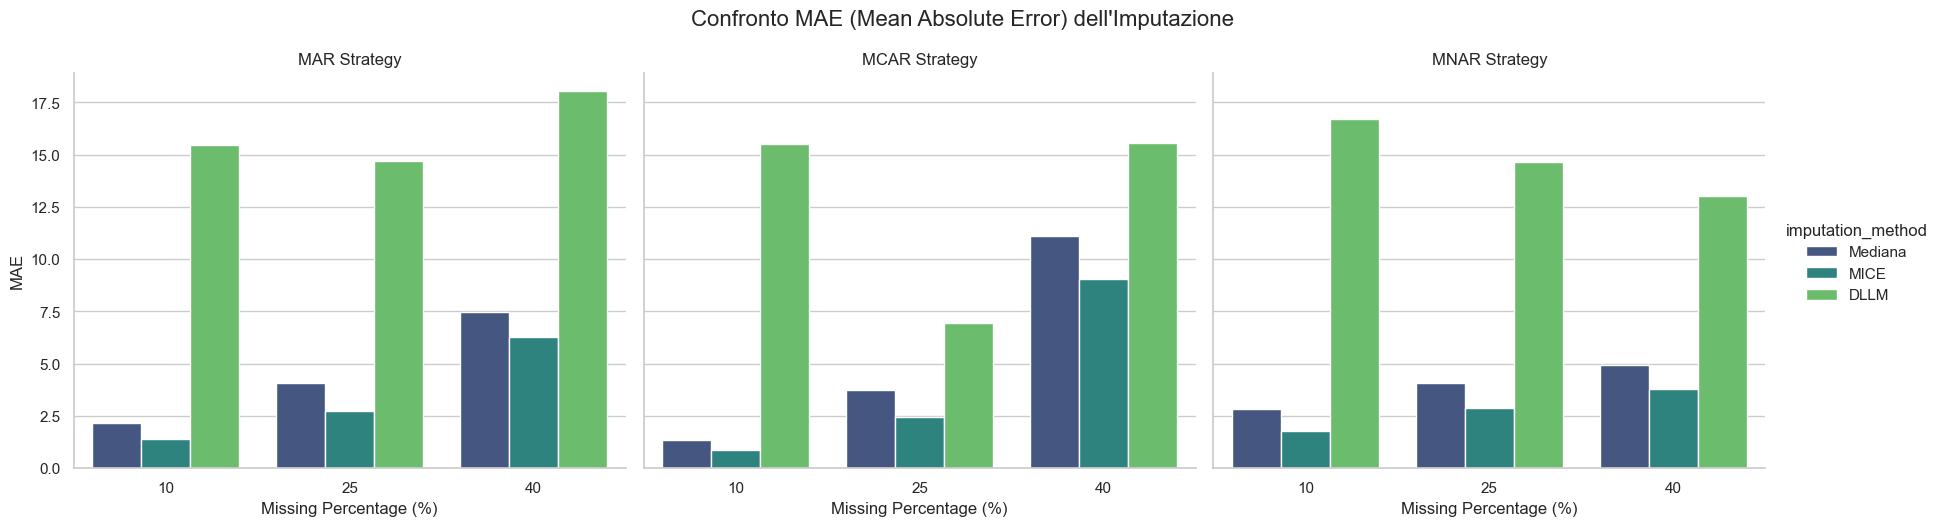

In [4]:
# Plot MAE
plot_comparison(df_imp, 'mae', "Confronto MAE (Mean Absolute Error) dell'Imputazione", 'MAE')

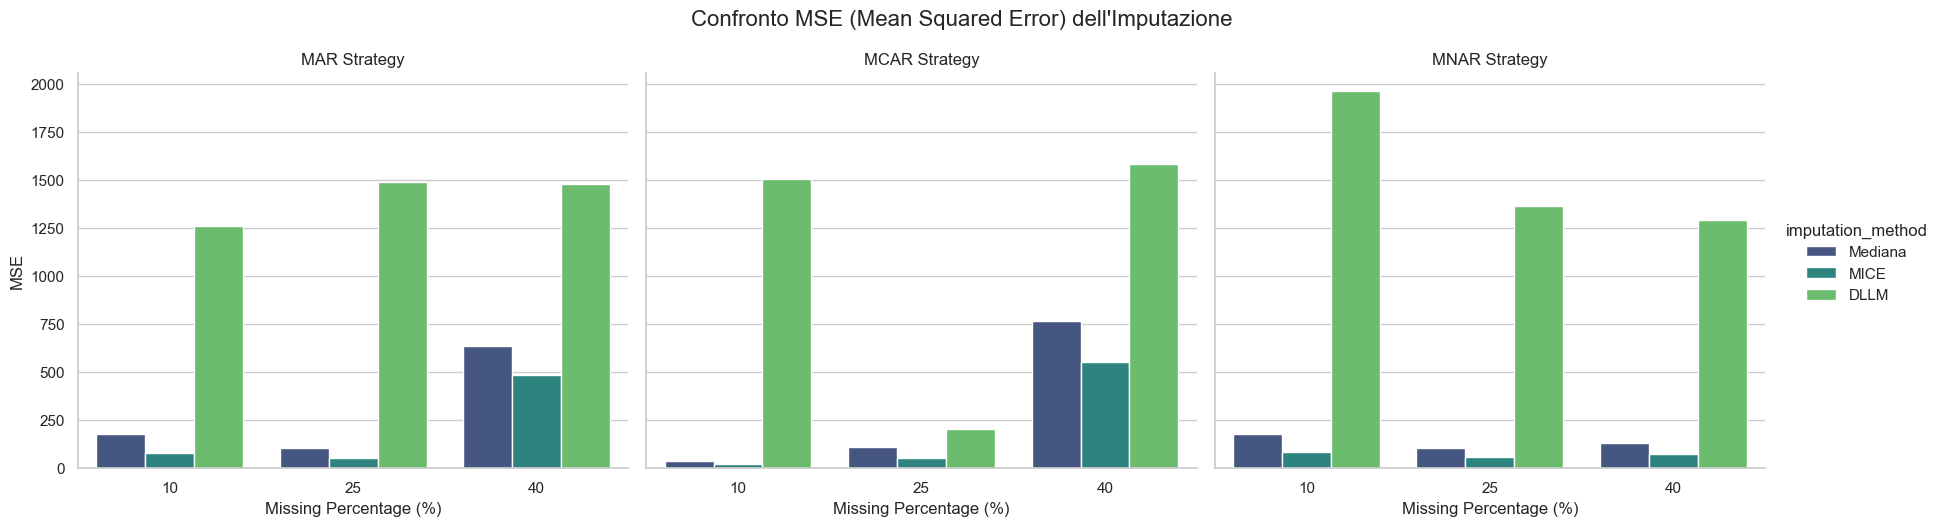

In [5]:
# Plot MSE
plot_comparison(df_imp, 'mse', "Confronto MSE (Mean Squared Error) dell'Imputazione", 'MSE')

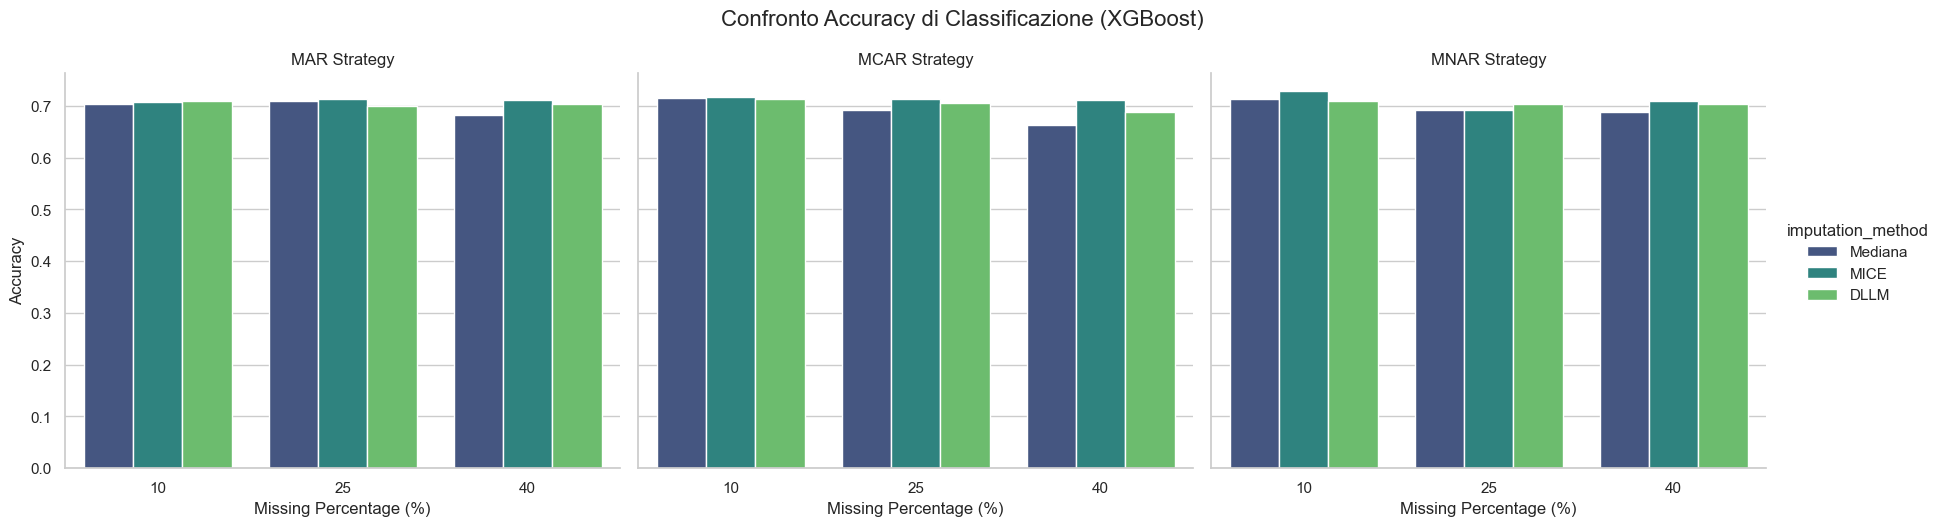

In [6]:
# Plot Accuracy
plot_comparison(df_discr, 'accuracy', 'Confronto Accuracy di Classificazione (XGBoost)', 'Accuracy')

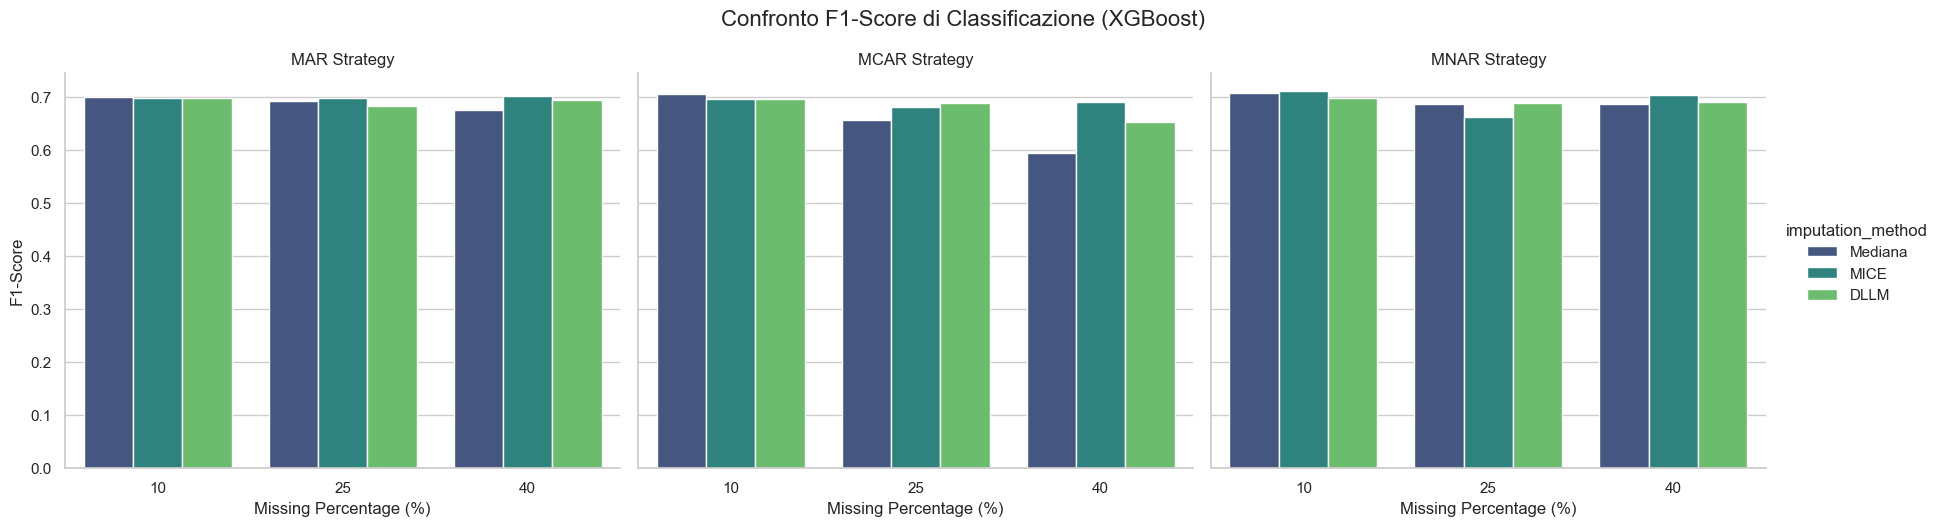

In [7]:
# Plot F1-Score
plot_comparison(df_discr, 'f1_score', 'Confronto F1-Score di Classificazione (XGBoost)', 'F1-Score')

In [8]:
print("=== Risultati Imputazione (Ordinati per MAE) ===")
display(df_imp.sort_values(by=['missing_strategy', 'missing_pct', 'mae']).reset_index(drop=True))

print("\n=== Risultati Classificazione (Ordinati per Accuracy) ===")
display(df_discr.sort_values(by=['missing_strategy', 'missing_pct', 'accuracy'], ascending=[True, True, False]).reset_index(drop=True))

=== Risultati Imputazione (Ordinati per MAE) ===


,imputation_method,dataset,missing_strategy,missing_pct,mse,mae
0,MICE,heloc_ML,MAR,10,77.389833,1.391432
1,Mediana,heloc_ML,MAR,10,179.052431,2.140418
2,DLLM,heloc_DLLM,MAR,10,1261.315425,15.473614
3,MICE,heloc_ML,MAR,25,52.295490,2.753907
4,Mediana,heloc_ML,MAR,25,104.873068,4.052135
5,DLLM,heloc_DLLM,MAR,25,1490.033433,14.702033
6,MICE,heloc_ML,MAR,40,486.805474,6.267326
7,Mediana,heloc_ML,MAR,40,635.648025,7.471515
8,DLLM,heloc_DLLM,MAR,40,1482.399138,18.021382
9,MICE,heloc_ML,MCAR,10,19.544473,0.892591



=== Risultati Classificazione (Ordinati per Accuracy) ===


,imputation_method,missing_strategy,missing_pct,accuracy,f1_score
0,DLLM,MAR,10,0.709023,0.698846
1,MICE,MAR,10,0.707672,0.698711
2,Mediana,MAR,10,0.703616,0.700580
3,MICE,MAR,25,0.712741,0.697724
4,Mediana,MAR,25,0.710037,0.692473
5,DLLM,MAR,25,0.698547,0.682110
6,MICE,MAR,40,0.710375,0.701706
7,DLLM,MAR,40,0.703616,0.693678
8,Mediana,MAR,40,0.683001,0.676105
9,MICE,MCAR,10,0.716458,0.695904
